In [7]:

import os  
import sys

from dotenv import load_dotenv, find_dotenv

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)
load_dotenv(find_dotenv())

import re

import openai


import torch
import hashlib
import tomllib
import leidenalg
import pandas as pd
import numpy as np
import igraph as ig
from copy import deepcopy


from glob import glob
from pdfminer.high_level import extract_text

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_voyageai.embeddings import VoyageAIEmbeddings
from langchain_core.output_parsers.json import SimpleJsonOutputParser


from src.utils.clustering import construct_knn_graph
from src.classes.data_types import Embeddings
from src.classes.sparse_embedding_network import SparseEmbeddingNetwork



from langchain_ollama import OllamaLLM
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)
load_dotenv(find_dotenv())
openai.api_key = os.environ["OPENAI_API_KEY"]
voyage_api_key = os.environ["VOYAGE_API_KEY"]
BASEPATH = os.path.join(os.path.expanduser("~"), "Documents", "OHBM")

In [34]:
poster_file = os.path.join(BASEPATH,'2025/ohbm_posters_2025.csv')
poster_df = pd.read_csv(poster_file)

poster_df

,ID,Number,Title,Abstract,Year,Authors,OHBM Cluster
0,400832356450,1,A Computational Study on Non-Invasive Temporal...,Drug treatments based on chemical compounds ha...,2025,925111939170,8
1,912097028489,2,Mesoscale emotion circuits related to medial p...,"In primates, how the experience of emotion (in...",2025,654096464472;916807302817;11956211526;64287711...,15
2,164189870081,3,Predicting Improvement in Parkinson’s Disease ...,"Parkinson’s Disease (PD), which affects at lea...",2025,317891332074;775943974489;279060685073;4909302...,23
3,479663662990,4,The Virtual Brain reveals sweet dynamics of de...,Deep Brain Stimulation (DBS) is a successful s...,2025,705517710089;198930486001;480441582313;6596103...,8
4,463133969159,5,Towards topography-driven stereotactic targeti...,The zona incerta (ZI)–a brain structure implic...,2025,923767081978;952048223109;542865651930;8062904...,23
...,...,...,...,...,...,...,...
2090,952055419175,2126,Subregional dynamics in the insula capture its...,"The insula is involved in diverse sensory, vis...",2025,415479771086;496891700006;2883999215;697849031...,1
2091,545816016946,2127,Mitochondrial Energy Deficits Alter Brain Acti...,Human brain function relies on an extraordinar...,2025,240815104845;253643887176;432046435945;8054593...,6
2092,395881234194,2128,Relationships between glycemic status and (sub...,Diabetes has been linked to structural brain a...,2025,30069118585;532882674459;116643317578;25641157...,17
2093,491216035008,2129,Prenatal Maternal Depressive Symptoms Impact N...,Maternal depression during pregnancy is associ...,2025,712090814145;787073157541;791821612753;5742810...,19


In [35]:
poster_df['ID']

0       400832356450
1       912097028489
2       164189870081
3       479663662990
4       463133969159
            ...     
2090    952055419175
2091    545816016946
2092    395881234194
2093    491216035008
2094    275918471195
Name: ID, Length: 2095, dtype: int64

In [39]:
def parse_directories():
    """
    Parse the directories from the configuration file.
    Returns:
    - directories: dict
    """
    with open('../config/directories.toml', 'rb') as f:
        configurations = tomllib.load(f)

    return configurations

def get_poster_data(text, year):
    """
    Extracts poster information from the text of a conference proceedings.

    Args:
        text (str): The text of the conference proceedings.
        year (int): The year of the conference.

    Returns:
        tuple: A tuple containing two pandas DataFrames:
            - poster_df (pd.DataFrame): DataFrame containing poster information.
            - author_df (pd.DataFrame): DataFrame containing author information.
    """

    posters = text.split("Poster No")[1:]

    poster_number = [int(re.search(r"\d+", poster).group()) for poster in posters if re.search(r"\d+", poster)]
    poster_title = [poster.split("\n\n")[1].split("\n\n")[0].strip() for poster in posters]
    
    
    poster_abstract = []
    for poster, number, title in zip(posters, poster_number, poster_title):
        print(f"poster no {number}: {title}")
        abstract = poster.split("Introduction:")[-1].split("References")[0].strip() if "Introduction:" in poster and "References" in poster else poster.split("Introduction:")[-1].strip() if "Introduction:" in poster else ""
        poster_abstract.append(abstract)
        
    #poster_abstract = ['Introduction: ' + poster.split("Introduction:")[1].split("References")[0].strip() if "Introduction" in poster and "References" in poster else poster.split("Introduction:")[1].strip() for poster in posters]

    author_ids, author_first_names, author_last_names = zip(*[get_authors(poster, title) for poster, title in zip(posters, poster_title)])

    ## remove "30TH ANNUAL MEETING OF THE ORGANIZATION FOR HUMAN BRAIN MAPPING • SEOUL • page_number" and "ABSTRACTS" and "31ST ANNUAL MEETING OF THE ORGANIZATION FOR HUMAN BRAIN MAPPING • BRISBANE • 2"

    poster_abstract = [re.sub(r"30TH ANNUAL MEETING OF THE ORGANIZATION FOR HUMAN BRAIN MAPPING • SEOUL • \d+", "", abstract) for abstract in poster_abstract]
    poster_abstract = [re.sub(r"ABSTRACTS", "", abstract) for abstract in poster_abstract]
    poster_abstract = [re.sub(r"31ST ANNUAL MEETING OF THE ORGANIZATION FOR HUMAN BRAIN MAPPING • BRISBANE • \d+", "", abstract) for abstract in poster_abstract]

    ## remove multiple linebreaks (whenever there are more than one)
    poster_abstract = [re.sub(r"\n+", "\n", abstract) for abstract in poster_abstract]

    poster_ids = [int(hashlib.sha1(f"{title}".encode()).hexdigest(), 16) % 10**12 for title in poster_title]

    poster_df = pd.DataFrame({
        "ID": poster_ids,
        "Number": poster_number,
        "Title": poster_title,
        "Abstract": poster_abstract,
        "Year": [year] * len(poster_number),
        "Authors": [';'.join(map(str, authors)) for authors in author_ids]
    })

    author_ids = [item for sublist in author_ids for item in sublist]
    author_first_names = [item for sublist in author_first_names for item in sublist]
    author_last_names = [item for sublist in author_last_names for item in sublist]

    author_df = pd.DataFrame({
        "ID": author_ids,
        "First Name(s)": author_first_names,
        "Last Name": author_last_names,
    })
    return poster_df, author_df

def get_authors(poster, title):
    """  
    Extracts author information from a poster text given its title.

    Args:
        poster (str): The text of the poster.
        title (str): The title of the poster.

    Returns:
        tuple: A tuple containing three lists:
            - author_ids (list of int): Unique identifiers for each author.
            - first_names (list of str): First names of the authors.
            - last_names (list of str): Last names of the authors.
    """


    authors_line = poster.split(title)[1].rsplit("\n", 1)[0].split("Introduction:")[0]
    authors = [
    m.group(1).strip()
    for m in re.finditer(r"([A-Za-zÀ-ÖØ-öø-ÿĀ-ž\s'-]+)(\d+)", authors_line)
    if len(m.group(1).strip()) > 1
    ]

    last_names = [author.rsplit(" ", 1)[-1].strip() for author in authors]
    first_names = [author.replace(" " + last_name, "").strip() for author, last_name in zip(authors, last_names)]
    author_ids = [int(hashlib.sha1(f"{f} {l}".encode()).hexdigest(), 16) % 10**12 for f, l in zip(first_names, last_names)]
    
    
    return author_ids, first_names, last_names

    

    

In [3]:
year = 2024
files = sorted(glob(os.path.join(BASEPATH, f"{year}/*.pdf")))

text = extract_text(files[0])
ohbm_posters, ohbm_authors = get_poster_data(text, year)

for file in files[1:]:
    text = extract_text(file)
    posters, authors = get_poster_data(text, year)
    ohbm_posters = pd.concat([ohbm_posters, posters], ignore_index=True)
    ohbm_authors = pd.concat([ohbm_authors, authors], ignore_index=True)

In [83]:
ohbm_posters = ohbm_posters[ohbm_posters["Year"] == 2024]

In [51]:
year = 2025
file = os.path.join(BASEPATH, f"{year}/OHBM_2025_Brisbane_Abstracts_3.pdf")

text = extract_text(file)



In [84]:
posters, authors = get_poster_data(text, year)

ohbm_posters = pd.concat([ohbm_posters, posters], ignore_index=True)
ohbm_authors = pd.concat([ohbm_authors, authors], ignore_index=True)

poster no 1: A Computational Study on Non-Invasive Temporal Interfering Neurostimulation in the Deep Brain
poster no 2: Mesoscale emotion circuits related to medial pulvinar revealed by INS-fMRI in macaque monkeys
poster no 3: Predicting Improvement in Parkinson’s Disease Patients using Location of Stimulation
poster no 4: The Virtual Brain reveals sweet dynamics of deep brain stimulation in Parkinson’s disease
poster no 5: Towards topography-driven stereotactic targeting of the zona incerta
poster no 6: Assessing Deep Brain Stimulation Efficacy in Epilepsy: Target Accuracy and Thalamic Pathology
poster no 7: “PICS”: a novel patient-specific landmark for thalamic surgical interventions
poster no 8: Invasive Mapping of Therapeutic Response to Deep Brain Stimulation for Obsessive 
Compulsive Disorder
poster no 9: Modeling of the simulation artifact and brain evoked potential elicited by direct stimulation
poster no 10: Integrating intracranial stimulation with brain connectivity in langu

In [85]:
# remove duplicate authors from ohbm authors
ohbm_authors = ohbm_authors.drop_duplicates(subset=["ID"], keep="first").reset_index(drop=True)

ohbm_authors

,ID,First Name(s),Last Name
0,554055728971,Skyler,Deutsch
1,928005793528,Katelyn,Vu
2,669976948486,Andrea,Fuentes
3,674442424661,Sarah,Wang
4,672845414654,Alastair,Martin
...,...,...,...
16203,267515575333,Natalie,Rhodes
16204,260355845697,Molly \nRea,Rea
16205,868573046067,Zoe,Tanner
16206,447105796870,Xavier De,Tiege


In [91]:
# save posters and authors
ohbm_posters.to_csv(os.path.join(BASEPATH, "ohbm_posters.csv"), index=False)
ohbm_authors.to_csv(os.path.join(BASEPATH, "ohbm_authors.csv"), index=False)

In [96]:
ohbm_posters[ohbm_posters['Year']==2024]

,ID,Number,Title,Abstract,Year,Authors
0,325328568701,1,Acute and longitudinal fMRI brain response to ...,Introduction: Deep brain stimulation (DBS) is ...,2024,554055728971;928005793528;669976948486;6744424...
1,949531110640,2,Neurocircuitry of apathy in Parkinson’s patien...,Introduction: Subthalamic nucleus deep brain s...,2024,970183833568;202799426721;668795653480;1601205...
2,491727952823,3,Neural circuitry underlying DBS treatment for ...,Introduction: Children with Autism Spectrum Di...,2024,618735070747;976692407586;604513731271;4435588...
3,62249925504,4,Habenula neurostimulation improves neuropsychi...,Introduction: Fragile X syndrome (FX) is the m...,2024,302472049660;618735070747;976692407586;4435588...
4,11456389223,5,Modulation of Human Spatial-temporal Memory by...,"Introduction: As a neuromodulation technique, ...",2024,467964158053;85947393277;94436552346;500241377...
...,...,...,...,...,...,...
2559,830090004088,2629,Unraveling the Intricate Connections between B...,Introduction: The demographic shift toward an ...,2024,492517775540;571465107300;755145126509;4132333...
2560,109020179305,2630,Two distinctive brain correlates for top-down ...,Introduction: Increasing studies with acupunct...,2024,605299458049;396103063526
2561,977331493325,2631,QSM for identiﬁcation of microstructural patho...,Introduction: Brain iron accumulation is a put...,2024,920972175347;853877456627;594736063370;7402139...
2562,672954527967,2632,Brain Iron and Neurotransmitter Analysis for P...,Introduction: Perturbations in excitatory and ...,2024,200213277238;23992430191;743971358238;94748597...


In [42]:
directories = parse_directories()
model_path = os.path.join('/media/mario/HDD/Data/NeuroScape', directories['public']['models'])
model_file = os.path.join(model_path, "domain_embedding_model.pth")

In [43]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [44]:
batch_size = 50
voyage_embedder = VoyageAIEmbeddings(model='voyage-large-2-instruct', batch_size=batch_size,
                                         voyage_api_key=voyage_api_key)

# define the model and load the pre-trained weights
input_dimension = 1024
hidden_dimensions =  [512, 256, 128]
output_dimension = 64

model = SparseEmbeddingNetwork(input_dimension=input_dimension,
                                 hidden_dimensions=hidden_dimensions,
                                 output_dimension=output_dimension).to(device)

model.load_state_dict(torch.load(model_file, map_location=device))
model.eval()

def embed_abstracts(abstracts, voyage_embedder, model, device, batch_size=25):
    """
    Embed a list of abstracts using the VoyageAI embedder and the sparse embedding model.

    Args:
    - abstracts: List of abstracts to embed.
    - voyage_embedder: The VoyageAI embedder to use.
    - model: The sparse embedding model to use.
    - device: The device to use (CPU or GPU).

    Returns:
    - embeddings: Numpy array of embeddings.
    """

    num_abstracts = len(abstracts)
    all_embeddings = []
    for i in range(0, num_abstracts, batch_size):
        batch_abstracts = abstracts[i:i+batch_size]
        batch_embeddings = voyage_embedder.embed_documents(batch_abstracts)
        batch_embeddings = torch.tensor(batch_embeddings, dtype=torch.float32).to(device)
        with torch.no_grad():
            batch_embeddings = model(batch_embeddings).cpu().numpy()
        all_embeddings.append(batch_embeddings)

    embeddings = np.vstack(all_embeddings)
    return embeddings

In [36]:
ohbm_posters = poster_df.copy()

In [45]:
poster_ids = ohbm_posters['ID'].values
poster_abstracts = ohbm_posters['Abstract'].tolist()

poster_embeddings = embed_abstracts(poster_abstracts,voyage_embedder, model, device, batch_size=batch_size)

In [3]:
poster_ids[0]

NameError: name 'poster_ids' is not defined

In [50]:
posters = Embeddings(pmids=poster_ids,
embeddings=poster_embeddings)

In [67]:
import h5py
from tqdm import tqdm
def save_embeddings(posters, filename):
    with h5py.File(filename, 'w') as file:
        # Create datasets for the attributes that are same across all entries
        pmids = file.create_dataset('pmid', (len(posters.pmids), ), dtype='i8')

        # Create a group for embeddings and adjacencies to handle variability in lengths
        embedding_group = file.create_group('embeddings')

        # Populate the datasets
        for i, embedding in tqdm(enumerate(posters.embeddings),
                               total=len(pmids)):

            pmids[i] = posters.pmids[i]
            embedding_group.create_dataset(str(i),
                                               data=np.array(
                                                   embedding),
                                               dtype='f')





In [68]:
poster_file = os.path.join(BASEPATH, "posters_2025v2.h5")
save_embeddings(posters, poster_file)

100%|██████████| 2095/2095 [00:00<00:00, 4328.23it/s]


In [66]:
print(posters.pmids[0])

400832356450


In [11]:
import h5py
def load_embeddings():
  with h5py.File(poster_file, 'r') as file:
    # Retrieve pmids to compute total number of posters
    pmids = file['pmid'][:]
    total_posters = len(pmids)

    # Retrieve embeddings
    embedding_group = file['embeddings']

    # Initialize embeddings array with zeros
    first_embedding = np.array(embedding_group[str(0)])
    embeddings = np.zeros((total_posters, first_embedding.shape[0]))

    # Assign embeddings
    for i in range(total_posters):
      embeddings[i] = np.array(embedding_group[str(i)])

  return embeddings, pmids

poster_file = os.path.join(BASEPATH, "posters_2025v2.h5")

poster_embeddings, poster_ids = load_embeddings()


/tmp/ipykernel_19444/3838308423.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  first_embedding = np.array(embedding_group[str(0)])
/tmp/ipykernel_19444/3838308423.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  embeddings[i] = np.array(embedding_group[str(i)])


In [13]:
num_neighbors = 20

edges, weights = construct_knn_graph(poster_embeddings, num_neighbors)
G_2025 = ig.Graph(edges=edges, directed=False)
G_2025.es['weight'] = weights
G_2025.vs['ID'] = poster_ids

Performing k-NN search...
Constructing edge list...


100%|██████████| 2095/2095 [00:00<00:00, 32567.25it/s]


Symmetrizing the graph...


100%|██████████| 2095/2095 [00:00<00:00, 86539.69it/s]


In [21]:
import faiss
from tqdm import tqdm
def construct_knn_graph_corrected(embeddings, k):
    """
    Constructs a symmetric k-NN graph, guaranteeing perfect alignment of edges and weights.
    """
    num_points, dim = embeddings.shape
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)

    print("Performing k-NN search...")
    distances, indices = index.search(embeddings, k)

    print("Constructing edge map to ensure alignment...")
    # Use a dictionary to store the unique edge and its weight.
    # This intrinsically links the edge (key) to its weight (value).
    edge_map = {}
    for i in tqdm(range(num_points)):
        for neighbor_idx, distance in zip(indices[i], distances[i]):
            if i != neighbor_idx:
                # Store the edge in a canonical order to handle duplicates from symmetrization
                edge = tuple(sorted((i, neighbor_idx)))
                edge_map[edge] = distance

    # When we convert the dictionary's keys and values to lists,
    # Python guarantees their orders will match.
    edges = list(edge_map.keys())
    weights = list(edge_map.values())

    return edges, weights

edges, weights = construct_knn_graph_corrected(poster_embeddings, num_neighbors)
G_2025 = ig.Graph(edges=edges, directed=False)
G_2025.es['weight'] = weights
G_2025.vs['ID'] = poster_ids

Performing k-NN search...
Constructing edge map to ensure alignment...


100%|██████████| 2095/2095 [00:00<00:00, 52124.64it/s]


In [22]:
graph_file = os.path.join(BASEPATH, 'poster_similarity_2025_v3.graphml')
G_2025.write(graph_file, format='graphml')

In [153]:
import matplotlib.pyplot as plt

idx_ref = 100

x = poster_embeddings[idx_ref]

similarity = poster_embeddings.dot(x)
similarity[idx_ref] = 0

idx_min = np.argmin(similarity)
idx_max = np.argmax(similarity)

print(ohbm_posters.iloc[idx_ref]['Title'])
print('---------')
print(ohbm_posters.iloc[idx_min]['Title'])
print(similarity[idx_min])
print('---------')
print(ohbm_posters.iloc[idx_max]['Title'])
print(similarity[idx_max])

Effect of left DLPFC electric ﬁeld magnitude on tDCS-induced resting brain connectivity changes
---------
Myelin packing marker through in vivo water gap mapping
-0.37431347
---------
Effects of transcranial electrical stimulation on primary visual cortex using resting-state fMRI
0.93867743


In [240]:
num_neighbors = 20

    
edges, weights = construct_knn_graph(poster_embeddings, num_neighbors)
G = ig.Graph(edges=edges, directed=False)
G.es['weight'] = weights

Performing k-NN search...
Constructing edge list...


100%|██████████| 4659/4659 [00:00<00:00, 41172.44it/s]


Symmetrizing the graph...


100%|██████████| 4659/4659 [00:00<00:00, 75884.27it/s]


modularity: 0.6692853368660207
found 49 clusters


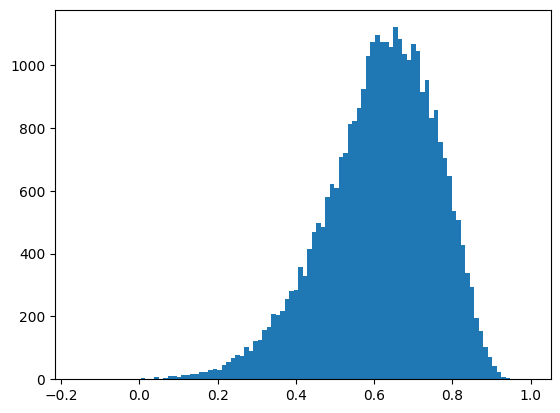

In [244]:
partition = leidenalg.find_partition(
            G,
            leidenalg.CPMVertexPartition,
            weights='weight',
            resolution_parameter=0.02)
print(f'modularity: {partition.modularity}')
print(f'found {len(np.unique(partition.membership))} clusters')




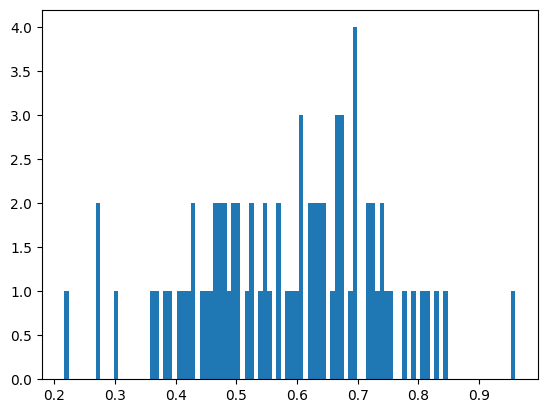

In [267]:
coi = 48

clusters = np.array(partition.membership)
cluster_embeddings = poster_embeddings[clusters==coi]

mask = np.triu(np.ones(len(cluster_embeddings)), k=1).astype(bool)
similarity = cluster_embeddings.dot(cluster_embeddings.T)[mask]
plt.hist(similarity, 100);

In [270]:
graph_file = os.path.join(BASEPATH, 'poster_similarity.graphml')
G.write(graph_file, format='graphml')
ohbm_posters.to_csv(os.path.join(BASEPATH, "ohbm_posters.csv"), index=False)

In [266]:
coi= 48
cluster_posters = ohbm_posters[ohbm_posters['OHBM Cluster']==coi].copy()

for row in cluster_posters.itertuples():
    print(row[3])
    print('----------------------------')

Chronic oxytocin attenuates amygdala activity but does not improve mirror system function in autism
----------------------------
Oxytocin alters fMRI intersubject correlation in psychotic disorders during emotional video watching
----------------------------
Late pregnancy oxytocin levels predict lower brain responses to infant cues at one-month postpartum
----------------------------
Oxytocin’s role on the central and autonomic neurophysiological correlates of salience attribution
----------------------------
Temporal Dynamics of Oxytocin in Aging: Putting the Tri-Phasic Model into the Test
----------------------------
Conducting tourism research based on RSA: A case study on brand extension problem
----------------------------
The Oxytocin Receptor Gene (OXTR) Dependent Intranasal Oxytocin Effect on Neural 
Responses to Trust
----------------------------
Cerebral expression and evolutionary annotation of oxytocin pathway genes
----------------------------
Announcement of the Oxytocin

In [2]:
posters_2025 = ohbm_posters[ohbm_posters['Year'] == 2025].copy()
years = ohbm_posters['Year'].values
ids_2025 = posters_2025['ID'].values
embeddings_2025 = poster_embeddings[years==2025]

NameError: name 'ohbm_posters' is not defined

In [292]:
num_neighbors = 20

    
edges, weights = construct_knn_graph(embeddings_2025, num_neighbors)
G_2025 = ig.Graph(edges=edges, directed=False)
G_2025.es['weight'] = weights

Performing k-NN search...
Constructing edge list...


  0%|          | 0/2095 [00:00<?, ?it/s]

100%|██████████| 2095/2095 [00:00<00:00, 43831.24it/s]


Symmetrizing the graph...


100%|██████████| 2095/2095 [00:00<00:00, 102054.16it/s]


In [1]:
weights

NameError: name 'weights' is not defined

modularity: 0.6618393472853236
found 23 clusters


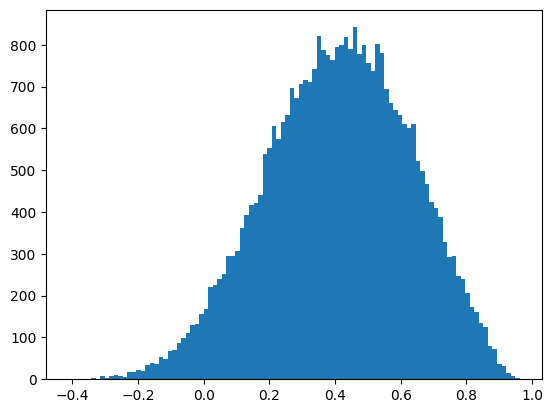

In [35]:
import matplotlib.pyplot as plt
partition = leidenalg.find_partition(
            G_2025,
            leidenalg.CPMVertexPartition,
            weights='weight',
            resolution_parameter=0.015)
print(f'modularity: {partition.modularity}')
print(f'found {len(np.unique(partition.membership))} clusters')


coi = 0

clusters = np.array(partition.membership)
cluster_embeddings = poster_embeddings[clusters==coi]

mask = np.triu(np.ones(len(cluster_embeddings)), k=1).astype(bool)
similarity = cluster_embeddings.dot(cluster_embeddings.T)[mask]
plt.hist(similarity, 100);

In [434]:
graph_file = os.path.join(BASEPATH, 'poster_similarity_2025.graphml')
G_2025.write(graph_file, format='graphml')
posters_2025['OHBM Cluster'] = partition.membership

posters_2025.to_csv(os.path.join(BASEPATH, "ohbm_posters_2025.csv"), index=False)

In [572]:
posters_embeddings_2025 = Embeddings(pmids=ids_2025,
embeddings=embeddings_2025)

poster_file = os.path.join(BASEPATH, "posters_2025.h5")
save_embeddings(posters_embeddings_2025, poster_file)

100%|██████████| 2095/2095 [00:00<00:00, 4498.42it/s]


In [40]:
poster_file

'/home/mario/Documents/OHBM/posters_2025v2.h5'

In [436]:
coi= 0
cluster_posters = posters_2025[posters_2025['OHBM Cluster']==coi].copy()

for row in cluster_posters.itertuples():
    print(row[3])
    print('----------------------------')

Longitudinal changes in hippocampal microstructure and functional connectivity in MDD following ECT
----------------------------
FNIRS Neurofeedback Targeting the lPFC Effectively and Sustainably Reduces Depressive Symptoms
----------------------------
NODDI-derived white matter changes after ECT in treatment-resistant depression
----------------------------
Real-Time fMRI Neurofeedback for Enhancing Positive Autobiographical Memory and 
Reducing Depression
----------------------------
Depressive Symptoms are Associated with Transcranial Photobiomodulation Target Engagement
----------------------------
Sex differences in functional brain connectivity signatures of personalized TMS outcomes
----------------------------
Depression-cognitive interaction affect amygdala functional connection in mild cognitive impairment
----------------------------
Key Effective Connectivity Alterations in Depression in Huntington’s Disease
----------------------------
ENIGMA-PD: Brain morphology correlate

In [361]:
from langchain_core.output_parsers.json import SimpleJsonOutputParser

from src.utils.semantic import safe_dictionary_extraction

In [ ]:
llm = ChatOpenAI(temperature=1.0,model_name='gpt-5.1', api_key='')

In [552]:
DEFINITION_PROMPT = ChatPromptTemplate.from_messages(
[
("system",
"You are an expert in science of science with formal training in philosophy of science and neuroscience. "
"You have a global, integrative overview of contemporary neuroscience and are careful to balance "
"abstraction with fidelity to empirical content."
),

("human",
"""
You are provided with a list of scientific abstracts that belong to a specific research cluster. Your task is to:

1. **Identify the most frequent and relevant keywords and phrases** used in the abstracts within this cluster.
   - Provide no more than 5 keywords.
   - Prefer *summary-level terms* that capture shared concepts across studies.
   - Avoid enumerating long lists of specific diseases, techniques, phenomena, or datasets when broader umbrella terms are appropriate.

2. **Provide a descriptive title** for the cluster that encapsulates the dominant themes and methodological approaches.
   - The title should be concise and abstract at the right level.
   - If multiple phenomena are studied, summarize them using a higher-level category
     (e.g., "neurodegenerative and cerebrovascular disorders" rather than listing diseases).
   - If multiple modalities are used, reflect this explicitly (e.g., multimodal, microstructural, vascular, molecular).

3. **Write a brief summary** (2–3 sentences) describing the main themes and methodologies of the cluster.
   - Emphasize what is common across the majority of abstracts.
   - Clearly distinguish:
       (a) what phenomena are being studied
       (b) how they are being measured or modeled
   - Do not overemphasize a single method or research question if the cluster is heterogeneous.

4. **Determine the main focus** of the cluster by choosing one of the following:
   - "Thematic" (driven by a shared biological or cognitive question),
   - "Methodological" (driven primarily by development or validation of methods),
   - "Methodologically driven thematic research" (advanced methods consistently applied to substantive scientific questions).

5. **Determine controversies** that are apparent within the cluster.
   - Only report controversies that arise from differences, limitations, or competing interpretations *within the provided abstracts*.
   - If no clear controversies are present, state "no controversies".

**Output Format (JSON only):**

{{
  "Keywords": ["keyword1", "keyword2", "keyword3", ...],
  "Title": "Descriptive Cluster Title",
  "Description": "Brief summary of the cluster's main themes and methodologies.",
  "Focus": "The main focus of the cluster.",
  "Controversy": "Any controversies that are apparent in the cluster."
}}

**Instructions:**
- Accuracy is crucial: all claims must be supported by the abstracts.
- Use abstraction to remain concise without distorting scope.
- Do not include any additional commentary beyond the JSON output.

**Here are the abstracts:**
{abstracts}
"""
)
],
)


METACLUSTER_PROMPT = ChatPromptTemplate.from_messages(
[
("system",
"You are an expert in science-of-science and neuroscience. You create high-level taxonomies of research fields. "
"You are careful: you must only use information in the provided cluster profiles and you must avoid inventing topics."
),
("human",
"""
You are given a set of research CLUSTERS. Each cluster is already summarized from many abstracts.

Your task is to build a small set of METACLUSTERS (superclusters) by grouping clusters that share a common organizing principle.

Hard constraints:
- Create **6–10 metaclusters** unless there are fewer than 12 clusters total.
- **Each cluster must appear in exactly ONE metacluster's MemberClusters**.
- If a cluster bridges two metaclusters, represent this ONLY via:
  (a) SecondaryMetaCluster in the Assignments table, and/or
  (b) listing it in BorderlineClusters of the relevant metacluster(s).
  Do NOT duplicate it in MemberClusters across metaclusters.
- Do not create a "miscellaneous" metacluster. If a metacluster is heterogeneous, split it.

Abstraction constraints:
- Use umbrella terms rather than listing many phenomena/diseases/methods.
- Titles should be program-like and interpretable.

For EACH metacluster provide:
- MetaTitle (concise)
- MetaDescription (2–3 sentences)
- InclusionCriteria (2–4 short phrases)
- MemberClusters (cluster IDs/titles exactly as provided)
- BorderlineClusters (may be empty)

For EACH input cluster provide:
- PrimaryMetaCluster (must match one MetaTitle)
- SecondaryMetaCluster (MetaTitle or null)
- Confidence (0.0–1.0)
- Rationale (one sentence grounded in the cluster profile)

Output JSON only in the schema below.

Schema:
{{
  "MetaClusters": [
    {{
      "MetaTitle": "...",
      "MetaDescription": "...",
      "InclusionCriteria": ["...", "..."],
      "MemberClusters": ["...", "..."],
      "BorderlineClusters": ["...", "..."]
    }}
  ],
  "Assignments": [
    {{
      "Cluster": "exact cluster title or ID",
      "PrimaryMetaCluster": "MetaTitle",
      "SecondaryMetaCluster": null,
      "Confidence": 0.0,
      "Rationale": "..."
    }}
  ]
}}

Here are the clusters:
{clusters}
"""
)
]
)

TAGGING_PROMPT = ChatPromptTemplate.from_messages(
[
("system",
"You are a meticulous scientific curator for a neuroimaging conference program. "
"You assign standardized tags to abstracts using ONLY the abstract text and the provided taxonomy. "
"You must follow the JSON schema exactly: fixed keys, fixed enums, no extra keys, no missing keys, no prose outside JSON. "
"If the abstract does not fit, mark it as borderline or out_of_scope rather than forcing a label."
),

("human",
"""
You are tagging abstracts for the cluster:
Neuroimaging Methods, Infrastructure, and Quantitative Microstructure.

You are given abstracts that were pre-assigned to this cluster because they touch upon
    - reliability/reproducibility, denoising, modeling, brain–behavior inference
    - infrastructure, automation, standards, AI pipelines, segmentation/synthesis/QC
    - diffusion/qMRI microstructure methods, tractometry, harmonization, normative modeling
    - physiology/neurovascular coupling, systemic confounds, biophysical modeling, interoception

Your job is to assign:
(1) PipelineStage
(2) ContributionType
(3) Fit quality for this cluster

────────────────────────────────────────────────────────
PIPELINE STAGES (choose exactly ONE)
Use these EXACT labels:

1) StandardsAndDataModels
Definition: Work whose main contribution is organizing neuroimaging data/metadata and outputs so they are findable, interoperable, and reusable.
Includes: BIDS (and extensions), metadata schemas, provenance data models, standard derivatives, atlases as standards, validators, dataset descriptors.
Excludes: algorithms that mainly improve image quality (use Reconstruction/Preprocessing), workflow engines/containers (use ComputeAndReproducibility).

2) ComputeAndReproducibility
Definition: Work whose main contribution is making analyses reproducible, scalable, and automatable across machines, labs, and datasets.
Includes: containers, workflow engines, orchestration, CI/testing, provenance tracking, QC automation, cloud/HPC scaling, end-to-end pipeline reproducibility.
Excludes: new acquisition sequences (Acquisition), denoising/distortion correction algorithms (Reconstruction), novel statistical models (ModelingAndInference).

3) AcquisitionAndProtocolDesign
Definition: Work whose main contribution is how data are acquired or protocols are designed and harmonized across sites/scanners.
Includes: sequence design, protocol optimization, sampling schemes (esp. diffusion/qMRI), calibration, site/vendor protocol harmonization at acquisition, prospective motion approaches.
Excludes: post-hoc harmonization of derived measures (ModelingAndInference), denoising/distortion correction (Reconstruction).

4) ReconstructionAndLowLevelCorrection
Definition: Work that improves raw image formation or fixes low-level artifacts before standard preprocessing/feature extraction.
Includes: denoising, bias field correction, distortion/motion correction, Gibbs/ringing, super-resolution, synthesis, missing-modality completion, anomaly detection, DL reconstruction/enhancement.
Excludes: segmentation/parcellation/tractometry (PreprocessingAndFeatureExtraction), statistical harmonization/normative modeling (ModelingAndInference).

5) PreprocessingAndFeatureExtraction
Definition: Work that turns images into analyzable features and representations.
Includes: segmentation, parcellation, tractography/tractometry, connectomes, microstructure metrics (as features), qMRI map derivation, feature engineering, standardized preprocessing variants.
Excludes: low-level artifact correction (Reconstruction), inferential modeling (ModelingAndInference), physiology validity modeling (PhysiologyAwareMeasurement unless it’s just feature extraction).

6) ModelingAndInference
Definition: Work whose main contribution is inference, statistics, machine learning, harmonization, or normative modeling on neuroimaging-derived measures.
Includes: reliability quantification, generalization testing, harmonization methods, normative modeling/brain charts, predictive models, calibration, uncertainty, benchmarking of inference frameworks.
Excludes: pipelines/tools without substantive modeling novelty (ToolOrPipeline under Compute/Reproducibility), biophysical neurovascular validity modeling (PhysiologyAwareMeasurement).

7) PhysiologyAwareMeasurement
Definition: Work where the core contribution is accounting for, modeling, or leveraging systemic physiology or neurovascular/biophysical mechanisms to interpret imaging signals.
Includes: neurovascular coupling, cerebrovascular reactivity, systemic low-frequency oscillations, cardiac/respiratory modeling, vascular “fingerprints”, confound disentanglement, biophysical forward models, interoception with physiology-informed signal interpretation.
Excludes: generic denoising unless physiology/vascular interpretation is central (then this stage applies).

────────────────────────────────────────────────────────
CONTRIBUTION TYPES (choose exactly ONE)
Use these EXACT labels:

- ToolOrPipeline: software, pipeline, workflow, library, container, integrated toolchain
- BenchmarkOrComparison: systematic evaluation or head-to-head comparison, challenge-style validation
- MethodOrAlgorithm: a new or substantially modified algorithm/method (not just an application)
- ResourceOrDataset: dataset, atlas, annotation resource, benchmark corpus, shared labels
- TheoryOrBiophysicalModel: mechanistic/biophysical/forward model or theory explicitly about measurement or signal generation
- ValidationOrMetrology: validation protocols, reliability, repeatability, uncertainty quantification, measurement validity
- ApplicationOrCaseStudy: primarily applying existing methods to a dataset/problem with limited methodological novelty

────────────────────────────────────────────────────────
FIT LABEL (choose exactly one)
- good: clearly belongs in this metacluster (methods/infrastructure/measurement)
- borderline: partly belongs but main thrust is elsewhere or spans multiple metaclusters
- out of scope: mainly substantive neuroscience/clinical finding with little methods/infrastructure contribution

────────────────────────────────────────────────────────
STRICT OUTPUT JSON SCHEMA
For EACH abstract output ONE object with EXACTLY these keys in EXACT casing:

{{
  "fit": "good|borderline|out of scope",
  "pipeline_stage": "StandardsAndDataModels|ComputeAndReproducibility|AcquisitionAndProtocolDesign|ReconstructionAndLowLevelCorrection|PreprocessingAndFeatureExtraction|ModelingAndInference|PhysiologyAwareMeasurement",
  "contribution_type": "ToolOrPipeline|BenchmarkOrComparison|MethodOrAlgorithm|ResourceOrDataset|TheoryOrBiophysicalModel|ValidationOrMetrology|ApplicationOrCaseStudy",
  "confidence": 0.00,
  "rationale": "string (1–2 sentences grounded in the abstract)"
}}

Rules:
- confidence must be a number between 0.00 and 1.00 with two decimals.
- Output must be a JSON array of objects, with no additional text.

Return EXACTLY one JSON object (not an array). 
The output must be valid JSON (no trailing commas, no comments, no markdown).

────────────────────────────────────────────────────────
INPUT

Tag the following abstract:
{abstract}
"""
)
]
)


DEBATE_PROMPT = ChatPromptTemplate.from_messages(
[
("system",
"You are a careful scientific annotator. Use ONLY the abstract text. "
"If the abstract does not address criticality, output no_position. "
"Return valid JSON only (no markdown, no trailing commas)."
),
("human",
"""
Annotate the abstract with respect to the controversy about brain criticality.

Definitions:
- pro_criticality: explicitly supports the idea that brain activity operates near criticality (or uses criticality as a central explanatory frame).
- anti_criticality: explicitly argues against near-criticality or emphasizes strong skepticism (e.g., evidence likely confounded/unsupported).
- conditional_or_mixed: says criticality depends on region, state, task, development/aging, or otherwise treats it as variable/conditional.
- methods_only: focuses on measuring/estimating criticality-related metrics without arguing for/against the criticality claim.
- no_position: does not address criticality (even if it studies dynamics generally).

Claim types (choose up to TWO; if none, use []):
- operating_point
- variability_distance
- mechanistic_function
- measurement_validity

Strength (integer 0–3):
0 = no_position
1 = weak/implicit
2 = moderate
3 = strong/explicit

Output EXACTLY one JSON object:
{{
  "stance": "pro_criticality|anti_criticality|conditional_or_mixed|methods_only|no_position",
  "claim_type": ["operating_point","..."],
  "strength": 0,
  "evidence": ["short paraphrased cue 1","short paraphrased cue 2"],
  "rationale": "1–2 sentences grounded in the abstract"
}}

Rules:
- evidence must be [] if stance is no_position.
- claim_type must be [] if stance is no_position.
- Do not invent measures or claims not in the abstract.

Abstract:
{abstract}
"""
)
]
)




In [455]:
definition_chain = DEFINITION_PROMPT | llm | SimpleJsonOutputParser()
metacluster_chain = METACLUSTER_PROMPT | llm | SimpleJsonOutputParser()

In [427]:
required_fields = ["Keywords", "Title", "Description", "Focus", "Controversy"]

retries = 5
delay = 0.2



In [437]:
unique_clusters = np.unique(clusters)

finished_clusters = []
cluster_definitions = []

for cluster in unique_clusters:
    print(f'Defining cluster {cluster}')
    if cluster in finished_clusters:
        continue
    cluster_posters = posters_2025[posters_2025['OHBM Cluster']==cluster].copy()
    abstracts = cluster_posters['Abstract'].tolist()

    abstracts_text = '\n'.join(abstracts)
    chain_input = {'abstracts': abstracts_text}
    cluster_json = safe_dictionary_extraction(required_fields, chain_input, definition_chain, retries=retries, delay=delay)

    finished_clusters.append(cluster)
    cluster_definitions.append(cluster_json)


    

Defining cluster 0
Defining cluster 1
Defining cluster 2
Defining cluster 3
Defining cluster 4
Defining cluster 5
Defining cluster 6
Defining cluster 7
Defining cluster 8
Defining cluster 9
Defining cluster 10
Defining cluster 11
Defining cluster 12
Defining cluster 13
Defining cluster 14
Defining cluster 15
Defining cluster 16
Defining cluster 17
Defining cluster 18
Defining cluster 19
Defining cluster 20
Defining cluster 21
Defining cluster 22
Defining cluster 23
Defining cluster 24
Defining cluster 25


In [563]:
cluster_file = os.path.join(BASEPATH, 'cluster_definitions.csv')

for definition in cluster_definitions:
    definition['Keywords'] = ';'.join(definition['Keywords'])


cluster_df = pd.DataFrame(cluster_definitions)
cluster_df['Cluster ID'] = unique_clusters
cluster_df.to_csv(cluster_file, index=False)

In [565]:
cluster_definitions[10]

{'Keywords': 'd;i;f;f;u;s;i;o;n; ;M;R;I; ;a;n;d; ;t;r;a;c;t;o;g;r;a;p;h;y;;;q;u;a;n;t;i;t;a;t;i;v;e; ;a;n;d; ;m;i;c;r;o;s;t;r;u;c;t;u;r;a;l; ;M;R;I;;;i;m;a;g;e; ;a;c;q;u;i;s;i;t;i;o;n; ;a;n;d; ;p;r;e;p;r;o;c;e;s;s;i;n;g; ;p;i;p;e;l;i;n;e;s;;;r;e;l;i;a;b;i;l;i;t;y;,; ;h;a;r;m;o;n;i;z;a;t;i;o;n;,; ;a;n;d; ;n;o;r;m;a;t;i;v;e; ;m;o;d;e;l;i;n;g;;;n;e;u;r;o;l;o;g;i;c;a;l; ;a;n;d; ;n;e;u;r;o;d;e;g;e;n;e;r;a;t;i;v;e; ;d;i;s;o;r;d;e;r;s',
 'Title': 'Advanced Diffusion and Quantitative MRI Methods for Reliable White Matter and Microstructural Biomarkers Across Disorders',
 'Description': 'This cluster centers on developing, validating, and benchmarking advanced MRI techniques—especially diffusion-based tractography and quantitative microstructural imaging—to characterize white matter architecture and tissue properties in health and a wide range of neurological and neurodegenerative conditions. Studies introduce new acquisition schemes, segmentation and tractometry frameworks, noise and bias corr

In [456]:
cluster_info = []

for i, definition in enumerate(cluster_definitions):
    text = f"Cluster {i} - {definition['Title']}\nKeywords: {definition['Keywords']}\nDescription: {definition['Description']}"
    cluster_info.append(text)

cluster_text = '\n\n'.join(cluster_info)

required_fields = ["MetaClusters", "Assignments"]

chain_input = {'clusters': cluster_text}

meta_json2 = safe_dictionary_extraction(required_fields, chain_input, metacluster_chain, retries=retries, delay=delay)

In [457]:
meta_json

{'MetaClusters': [{'MetaTitle': 'Transdiagnostic Network Biomarkers in Psychiatric and Neurodevelopmental Disorders',
   'MetaDescription': 'This metacluster covers multimodal, network-based neuroimaging of major psychiatric and neurodevelopmental conditions, emphasizing large-scale connectivity, gradients, and structure–function coupling as biomarkers. Work here seeks to subtype individuals, model heterogeneity and trajectories, and predict symptoms and treatment response using normative and machine-learning frameworks across depression, psychosis, ADHD, autism, addictions, and early-environmental risk.',
   'InclusionCriteria': ['Primary focus on psychiatric or neurodevelopmental disorders',
    'Large-scale brain networks and connectivity as core explanatory constructs',
    'Multimodal imaging combined with advanced statistical or machine-learning models',
    'Emphasis on biomarkers, subtyping, normative modeling, or outcome prediction'],
   'MemberClusters': ['Cluster 0 - Network

In [458]:
meta_json2 = safe_dictionary_extraction(required_fields, chain_input, metacluster_chain, retries=retries, delay=delay)

In [459]:
meta_json2 # this one is better!

{'MetaClusters': [{'MetaTitle': 'Transdiagnostic Network Biomarkers of Psychiatric and Neurodevelopmental Disorders',
   'MetaDescription': 'This metacluster covers multimodal, network-centric neuroimaging studies of common psychiatric and neurodevelopmental conditions, emphasizing individual differences, subtyping, and prediction of clinical outcomes. Work combines structural, functional, neurochemical, and peripheral biological measures to derive biomarkers of symptom dimensions, risk states, and treatment response across mood, psychosis, anxiety, addiction, ADHD, and autism.',
   'InclusionCriteria': ['Primary focus on psychiatric or neurodevelopmental disorders',
    'Emphasis on large-scale brain networks and connectivity',
    'Multimodal biomarkers and normative/individualized modeling',
    'Links to symptoms, cognition, risk, and treatment outcomes'],
   'MemberClusters': ['Cluster 0 - Network- and Inflammation-Based Biomarkers of Depression and Mood Dysregulation from Multimo

In [536]:
import json 

met_cluster_file = os.path.join(BASEPATH, "metacluster_file.json")

with open(met_cluster_file, "w") as f:
    json.dump(meta_json2, f)

    

In [398]:
cluster = 0

cluster_posters = posters_2025[posters_2025['OHBM Cluster']==cluster].copy()
abstracts = cluster_posters['Abstract'].tolist()

abstracts_text = '\n'.join(abstracts)

chain_input = {'cluster_json': cluster_definitions[0],'abstracts': abstracts_text}

feedback = evaluation_chain.invoke(chain_input)

In [402]:
print(feedback.content)

The cluster description you were given captures many broad themes correctly (neurodegeneration, multimodal imaging, networks, machine learning, glymphatic/ALPS, tau vs amyloid, brain‑age, etc.), but it is too narrow and somewhat misleading for this particular set of abstracts. Below is targeted feedback on each requested element and how it could be improved.

---

### 1. Keywords

**Issue:**  
The keyword set is only partially aligned with this cluster. It emphasizes:

- “Alzheimer’s disease and related dementias; Parkinson’s disease and Lewy body disorders”
- “Multimodal neuroimaging biomarkers (structural, diffusion, PET, fMRI, EEG/MEG)”
- “Brain connectivity, networks, and gradients”
- “Machine learning, normative and progression modeling for early detection and prognosis”

These are indeed present, but they don’t reflect the full breadth or the *balance* of methods and diseases in this cluster.

**What’s missing / underweighted:**

- Other diseases:  
  - Frontotemporal dementia (b

In [503]:
""" 
"fit": "good|borderline|out of scope",
  "pipeline stage (primary)": "StandardsAndDataModels|ComputeAndReproducibility|AcquisitionAndProtocolDesign|ReconstructionAndLowLevelCorrection|PreprocessingAndFeatureExtraction|ModelingAndInference|PhysiologyAwareMeasurement",
  "pipeline stage (secondary)": "StandardsAndDataModels|ComputeAndReproducibility|AcquisitionAndProtocolDesign|ReconstructionAndLowLevelCorrection|PreprocessingAndFeatureExtraction|ModelingAndInference|PhysiologyAwareMeasurement|null",
  "contribution type (primary)": "ToolOrPipeline|BenchmarkOrComparison|MethodOrAlgorithm|ResourceOrDataset|TheoryOrBiophysicalModel|ValidationOrMetrology|ApplicationOrCaseStudy",
  "contribution type (secondary)": "ToolOrPipeline|BenchmarkOrComparison|MethodOrAlgorithm|ResourceOrDataset|TheoryOrBiophysicalModel|ValidationOrMetrology|ApplicationOrCaseStudy|null",
  "confidence": 0.00,
  "rationale": 
"""

gemma_llm = OllamaLLM(model="gemma2:9b")
tagging_chain = TAGGING_PROMPT | gemma_llm | SimpleJsonOutputParser()

required_fields = ['fit', 'pipeline_stage','contribution_type', 'confidence', 'rationale']

In [523]:
clusters = [2, 3, 10, 16]

abstract_tags = []
finished = set()   # use a set for O(1) lookup

for cluster_id in clusters:
    cluster_df = posters_2025[posters_2025['OHBM Cluster'] == cluster_id]

    for _, row in cluster_df.iterrows():
        abstract = row['Abstract']
        abstract_id = row['ID']

        if abstract_id in finished:
            continue

        chain_input = {'abstract': abstract}
        abstract_tag = safe_dictionary_extraction(
            required_fields,
            chain_input,
            tagging_chain,
            retries,
            delay
        )

        abstract_tags.append(abstract_tag)
        finished.add(abstract_id)


In [527]:

abstract_ids = []
for cluster_id in clusters:
    cluster_df = posters_2025[posters_2025['OHBM Cluster'] == cluster_id]

    for _, row in cluster_df.iterrows():
        abstract_id = row['ID']

        abstract_ids.append(abstract_id)

In [530]:
methods_tags_df = pd.DataFrame(abstract_tags)

methods_tags_df['ID'] = abstract_ids

In [534]:
methods_tags_file = os.path.join(BASEPATH, '2025_method_tagging.csv')

methods_tags_df.to_csv(met_cluster_file)

In [553]:
"""  
{
  "stance": "intrinsic_mechanism|epiphenomenon_artifact|mixed_or_conditional|no_position|not_relevant",
  "strength": 0,
  "evidence": ["short paraphrased phrase 1", "short paraphrased phrase 2"],
  "rationale": "1-2 sentences explaining the choice, grounded in the abstract"

"stance": "pro_criticality|anti_criticality|conditional_or_mixed|methods_only|no_position",
  "claim_type": ["operating_point","..."],
  "strength": 0,
  "evidence": ["short paraphrased cue 1","short paraphrased cue 2"],
  "rationale": "1–2 sentences grounded in the abstract"

"""


debate_chain = DEBATE_PROMPT | gemma_llm | SimpleJsonOutputParser()

required_fields = ['stance', 'claim_type', 'strength', 'evidence', 'rationale']

In [570]:
cluster_id = 1
cluster_df = posters_2025[posters_2025['OHBM Cluster'] == cluster_id]

debate_tags = []

finished = set()

for _, row in cluster_df.iterrows():
    abstract = row['Abstract']
    abstract_id = row['ID']

    if abstract_id in finished:
        continue

    chain_input = {'abstract': abstract}
    abstract_tag = safe_dictionary_extraction(
            required_fields,
            chain_input,
            debate_chain,
            retries,
            delay
        )
    print(abstract_tag)




{'stance': 'no_position', 'claim_type': [], 'strength': 0, 'evidence': [], 'rationale': ''}
{'stance': 'no_position', 'claim_type': [], 'strength': 0, 'evidence': [], 'rationale': ''}
{'stance': 'no_position', 'claim_type': [], 'strength': 0, 'evidence': [], 'rationale': 'The abstract focuses on the impact of subcortical infarction on functional connectivity and cortical hierarchy organization, without mentioning criticality or related concepts.'}
{'stance': 'no_position', 'claim_type': [], 'strength': 0, 'evidence': [], 'rationale': ''}
{'stance': 'no_position', 'claim_type': [], 'strength': 0, 'evidence': [], 'rationale': "The abstract focuses on identifying shared brain networks across cognitive domains (memory, semantics, mentalizing) using resting-state functional connectivity. It doesn't discuss criticality or its potential role."}
{'stance': 'no_position', 'claim_type': [], 'strength': 0, 'evidence': [], 'rationale': ''}
{'stance': 'no_position', 'claim_type': [], 'strength': 0,

In [568]:
print(abstract)

Neurological conditions such as stroke and glioma are major causes of disability worldwide, accounting for 
millions of deaths per year and long-lasting cognitive impairments1. Recent studies show that brain network disruption can 
predict survival rates in glioma and model cognitive impairment in stroke2,3. However, a similar connectivity framework to 
model cognitive functioning after surgery is currently lacking. Here, we introduce a novel method that integrates direct 
electrical brain stimulation (DES) with MRI-driven functional network mapping to recover the white matter substrates causally 
implicated in language production.
Methods: Recent evidence suggests that spontaneous hemodynamic oscillations in the white matter map into distributed 
functional brain networks with distinct neurophysiological underpinnings4-6. In line with these observations, we used white 
matter DES points causing transient speech arrest, semantic or phonological aphasia (N=297 patients, 486 stimulation

In [41]:
poster_df = pd.read_csv(os.path.join(BASEPATH, "2025/ohbm_posters_2025.csv"))

In [44]:
print(poster_df[poster_df['ID']==811538240801]['Abstract'].values[0])

Replication is a cornerstone of scientific research, but achieving robust results that can be replicated remains 
a challenge in neuroimaging. The problem stems from the high degree of flexibility in data processing and analysis choices, 
known as the “researcher’s degrees of freedom”, which can affect scientific results. Multiverse analysis addresses this 
problem by systematically exploring the impact of alternative analytical choices on the results of hypothesis tests. By running 
analyses through a range of defensible pipeline options, multiverse analysis tests robustness, a core aspect of replicability. 
This study examines the robustness of findings on how prematurity affects neonatal brain connectivity using multiverse 
analysis. The focus is on the audio-visual integration (AVI) brain network, a key system for perceptual and ultimately socio-
cognitive development. Using fMRI data from the Developing Human Connectome Project (dHCP), we tested the robustness 
of the association 